# Classification with Decision Trees

This lab explores Decision Tree classification using the **Iris dataset**.

Two approaches are implemented and compared:

- **From scratch**: implement the core concepts behind Decision Tree classification, including Entropy and Information Gain.

- **Scikit-learn**: use `DecisionTreeClassifier` with different splitting criteria:
  - Entropy (ID3)
  - Log Loss
  - Gini (CART)

The models are visualized and evaluated using cross-validation.

1. Dataset & Preprocessing
2. Build Decision Tree from Scratch
   - Entropy
   - Information Gain
   - ID3
   - C4.5 discussion
3. Decision Tree with Scikit-learn
   - Entropy
   - Gini (CART)
4. Visualization
5. Cross-validation
6. Comparison & Conclusion

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# 1. Dataset & Preprocessin

In [2]:
# Load Iris dataset
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)


In [3]:
# Create data frame
df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Data frame shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Data frame shape: (150, 5)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [5]:
# Descriptive Statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
print("Class distribution:")
print(df["target"].value_counts().sort_index())  # Sort by value

print("\nClass names:")
for i, name in enumerate(iris.target_names):
    print(f"{i}: {name}")

Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

Class names:
0: setosa
1: versicolor
2: virginica


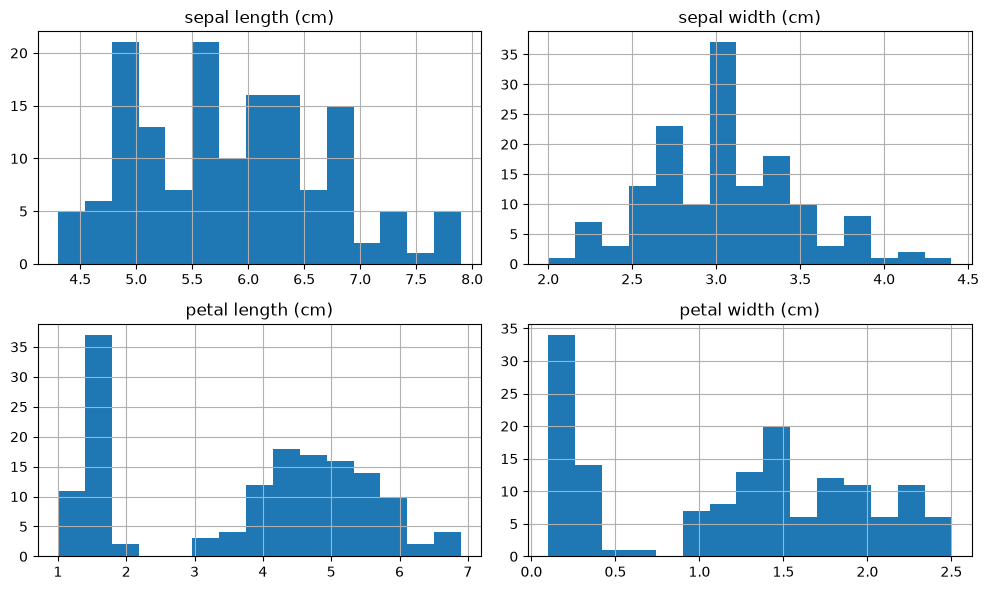

In [7]:
# Feature distribution
df.iloc[:, :4].hist(figsize=(10,6), bins=15)

plt.tight_layout()
plt.show()

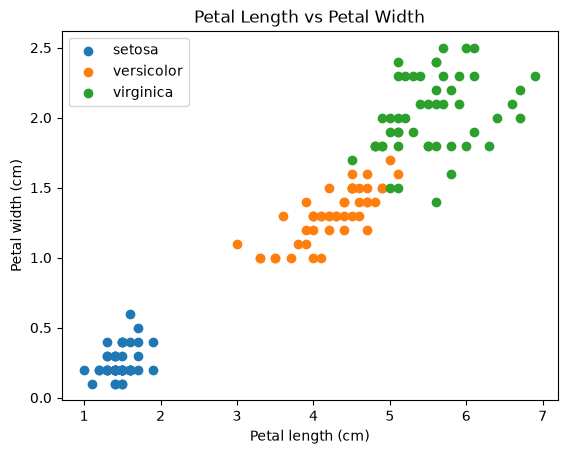

In [8]:
# Feature Relationship
for class_id, class_name in enumerate(iris.target_names):
    subset = df[df["target"] == class_id]

    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=class_name
    )

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.show()

## Preprocessing

The Iris dataset contains only numerical input features, so no categorical encoding is required.

Since Decision Trees are not sensitive to feature scale, feature scaling is also unnecessary.

We split the dataset into training and test sets while preserving the class distribution using stratified sampling.

In [9]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :4]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Training set: (120, 4)
Test set: (30, 4)

Training class distribution:
target
0    40
1    40
2    40
Name: count, dtype: int64

Test class distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


# 2. Build Decision Tree from Scratch

## 2.1 Entropy - Information Gain

1. Entropy 
$$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

Where:
* $S$: The current dataset.
* $c$: The number of distinct classes.
* $p_i$: The proportion (probability) of samples belonging to class $i$.

Entropy measures the **impurity**, **uncertainty**, or **randomness** of a dataset:

* **High Entropy:** Classes are mixed together (high uncertainty, hard to predict). Maximum when classes are equally split (e.g., 50% Yes / 50% No).
* **Low Entropy (0):** The dataset is completely pure (all samples belong to a single class, zero uncertainty).

In Decision Trees, the goal is to split data so that the resulting subsets have the lowest possible entropy.

In [10]:
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)         # Return two np array
    probabilities = counts/len(y)

    return -np.sum(probabilities * np.log2(probabilities))

In [11]:
print("Training set entropy:", entropy(y_train))

Training set entropy: 1.584962500721156


2. Information Gain
$$IG(S, A) = H(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

Where:
* $S$: The parent dataset.
* $A$: The feature/attribute used for splitting.
* $\text{Values}(A)$: All possible values of feature $A$.
* $S_v$: The subset of $S$ where feature $A$ has value $v$.
* $|S_v| / |S|$: The weight (proportion) of subset $S_v$ relative to $S$.
* $H(S_v)$: The entropy of subset $S_v$.

Information Gain measures the **reduction in entropy** (or uncertainty) achieved by splitting a dataset on a specific feature:

* **High Information Gain:** The feature effectively separates classes into purer subsets.
* **Low Information Gain (0):** The split provides little to no improvement in class purity.

In Decision Trees, the feature with the **highest Information Gain** is selected at each step to split the data.

In [12]:
def information_gain(y, y_left, y_right):
    parent_entropy = entropy(y)

    left_weight = len(y_left)/len(y)
    right_weight = len(y_right)/len(y)

    weighted_entropy = (
        left_weight * entropy(y_left)
        + right_weight * entropy(y_right)
    )

    return parent_entropy - weighted_entropy

In [13]:
# Split on 1 feature

feature = "petal width (cm)"
threshold = 0.8

left = y_train[X_train[feature] <= threshold]
right = y_train[X_train[feature] > threshold]

ig = information_gain(y_train, left, right)

print("Feature:", feature)
print("Threshold:", threshold)
print("Left samples:", len(left))
print("Right samples:", len(right))
print("Information Gain:", ig)

Feature: petal width (cm)
Threshold: 0.8
Left samples: 40
Right samples: 80
Information Gain: 0.9182958340544894


## 2.2. Recursive Tree Building

We can define and build the tree recursively.

In [14]:
# Define a Node
class Node:
    def __init__(self,
                feature = None,
                threshold = None, 
                left = None,
                right = None,
                prediction = None):
        self.feature = feature                   # feature used for split
        self.threshold = threshold               # threshold for split 
        self.left = left
        self.right = right
        self.prediction = prediction


Function to find the best split

In [15]:
def find_best_split(X, y):
    best_gain = -1
    best_feature = None
    best_threshold = None

    for feature in X.columns:
        # Lấy các giá trị unique đã được sắp xếp tăng dần
        values = np.sort(X[feature].unique())
        
        # Tính midpoints (điểm giữa) cho các ngưỡng threshold
        midpoints = (values[:-1] + values[1:]) / 2

        for threshold in midpoints:
            left_mask = X[feature] <= threshold
            right_mask = X[feature] > threshold

            y_left = y[left_mask]
            y_right = y[right_mask]

            # Bỏ qua nếu có nhánh rỗng
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gain = information_gain(y, y_left, y_right)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain


Recursively build tree

In [16]:
def build_tree(X, y, depth=0, max_depth=5):
    # If all samples belong to one class -> leaf
    if len(np.unique(y)) == 1:
        prediction = y.iloc[0]
        return Node(prediction=prediction)

    # Stop if maximum depth is reached
    if depth >= max_depth:
        prediction = y.value_counts().idxmax()
        return Node(prediction=prediction)

    # Find the best split
    feature, threshold, gain = find_best_split(X, y)

    # If no useful split is found
    if feature is None or gain <= 0:
        prediction = y.value_counts().idxmax()
        return Node(prediction=prediction)

    # Split data
    left_mask = X[feature] <= threshold
    right_mask = X[feature] > threshold

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    # Recursively build children
    left_child = build_tree(
        X_left,
        y_left,
        depth + 1,
        max_depth
    )

    right_child = build_tree(
        X_right,
        y_right,
        depth + 1,
        max_depth
    )

    return Node(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child
    )


Train Scratch Decision Tree


In [17]:
tree = build_tree(X_train, y_train, max_depth=5)
print("Decision Tree from scratch trained successfully.")


Decision Tree from scratch trained successfully.


Predict one sample

In [18]:
def predict_one(node, sample):
    # Leaf node
    if node.prediction is not None:
        return node.prediction

    if sample[node.feature] <= node.threshold:
        return predict_one(node.left, sample)
    else:
        return predict_one(node.right, sample)


Predict whole dataset

In [19]:
def predict_tree(tree, X):
    predictions = []

    for _, sample in X.iterrows():
        prediction = predict_one(tree, sample)
        predictions.append(prediction)

    return np.array(predictions)


Evaluate Scratch Tree


In [20]:
from sklearn.metrics import accuracy_score

y_pred_scratch = predict_tree(tree, X_test)

accuracy_scratch = accuracy_score(
    y_test,
    y_pred_scratch
)

print("Scratch Decision Tree Accuracy:", accuracy_scratch)


Scratch Decision Tree Accuracy: 0.9333333333333333


Print tree

In [21]:
def print_tree(node, depth=0):
    indent = "    " * depth

    if node.prediction is not None:
        print(
            indent +
            f"Leaf -> Class {node.prediction}"
        )
        return

    print(
        indent +
        f"{node.feature} <= {node.threshold}"
    )

    print(indent + "├── True:")
    print_tree(node.left, depth + 1)

    print(indent + "└── False:")
    print_tree(node.right, depth + 1)


In [22]:
print_tree(tree)

petal length (cm) <= 2.45
├── True:
    Leaf -> Class 0
└── False:
    petal width (cm) <= 1.65
    ├── True:
        petal length (cm) <= 4.95
        ├── True:
            Leaf -> Class 1
        └── False:
            sepal length (cm) <= 6.15
            ├── True:
                sepal width (cm) <= 2.45
                ├── True:
                    Leaf -> Class 2
                └── False:
                    Leaf -> Class 1
            └── False:
                Leaf -> Class 2
    └── False:
        petal length (cm) <= 4.85
        ├── True:
            sepal width (cm) <= 3.0
            ├── True:
                Leaf -> Class 2
            └── False:
                Leaf -> Class 1
        └── False:
            Leaf -> Class 2


# 3. Decision Tree using Scikit-learn

Now we using Scikit-learn to build a Decision Tree

In [23]:
# Lib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## ID3 Algorithm
In ID3 algorithm, we compute Entropy and then Information Gain. For each split, we choose the attribute which provide the higest IG.

In [24]:
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)

accuracy_entropy = accuracy_score(
    y_test,
    y_pred_entropy
)

print("Entropy Accuracy:", accuracy_entropy)

Entropy Accuracy: 0.9333333333333333


## Log Loss

In [25]:
dt_log_loss = DecisionTreeClassifier(
    criterion="log_loss",
    random_state=42
)

dt_log_loss.fit(X_train, y_train)

y_pred_log_loss = dt_log_loss.predict(X_test)

accuracy_log_loss = accuracy_score(
    y_test,
    y_pred_log_loss
)

print("Log Loss Accuracy:", accuracy_log_loss)

Log Loss Accuracy: 0.9333333333333333


## Gini - CART

**Gini Impurity** is the core criterion used in the **CART** algorithm to measure the degree of impurity or mixture of classes at a specific node.

**Formula:**
$$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$$
*(Where: $p_i$ is the proportion of elements belonging to class $i$ in dataset $S$)*

**Key Characteristics:**
* **$Gini = 0$:** Best case (Pure node, 100% of the data belongs to a single class).
* **$Gini > 0$:** Mixed data. The higher the value, the greater the impurity (Max = 0.5 for a 50/50 binary classification).
* **Application in CART:** The algorithm always prioritizes the split that results in the **lowest** total Gini impurity for the child nodes.

In [26]:
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_gini.fit(X_train, y_train)

y_pred_gini = dt_gini.predict(X_test)

accuracy_gini = accuracy_score(
    y_test,
    y_pred_gini
)

print("Gini Accuracy:", accuracy_gini)

Gini Accuracy: 0.9333333333333333


## Compare Three Criteria

In [27]:
results = pd.DataFrame({
    "Criterion": [
        "Entropy",
        "Log Loss",
        "Gini"
    ],
    "Accuracy": [
        accuracy_entropy,
        accuracy_log_loss,
        accuracy_gini
    ]
})

results

,Criterion,Accuracy
0,Entropy,0.933333
1,Log Loss,0.933333
2,Gini,0.933333


# Visualize Decision Tree — Entropy/Gini

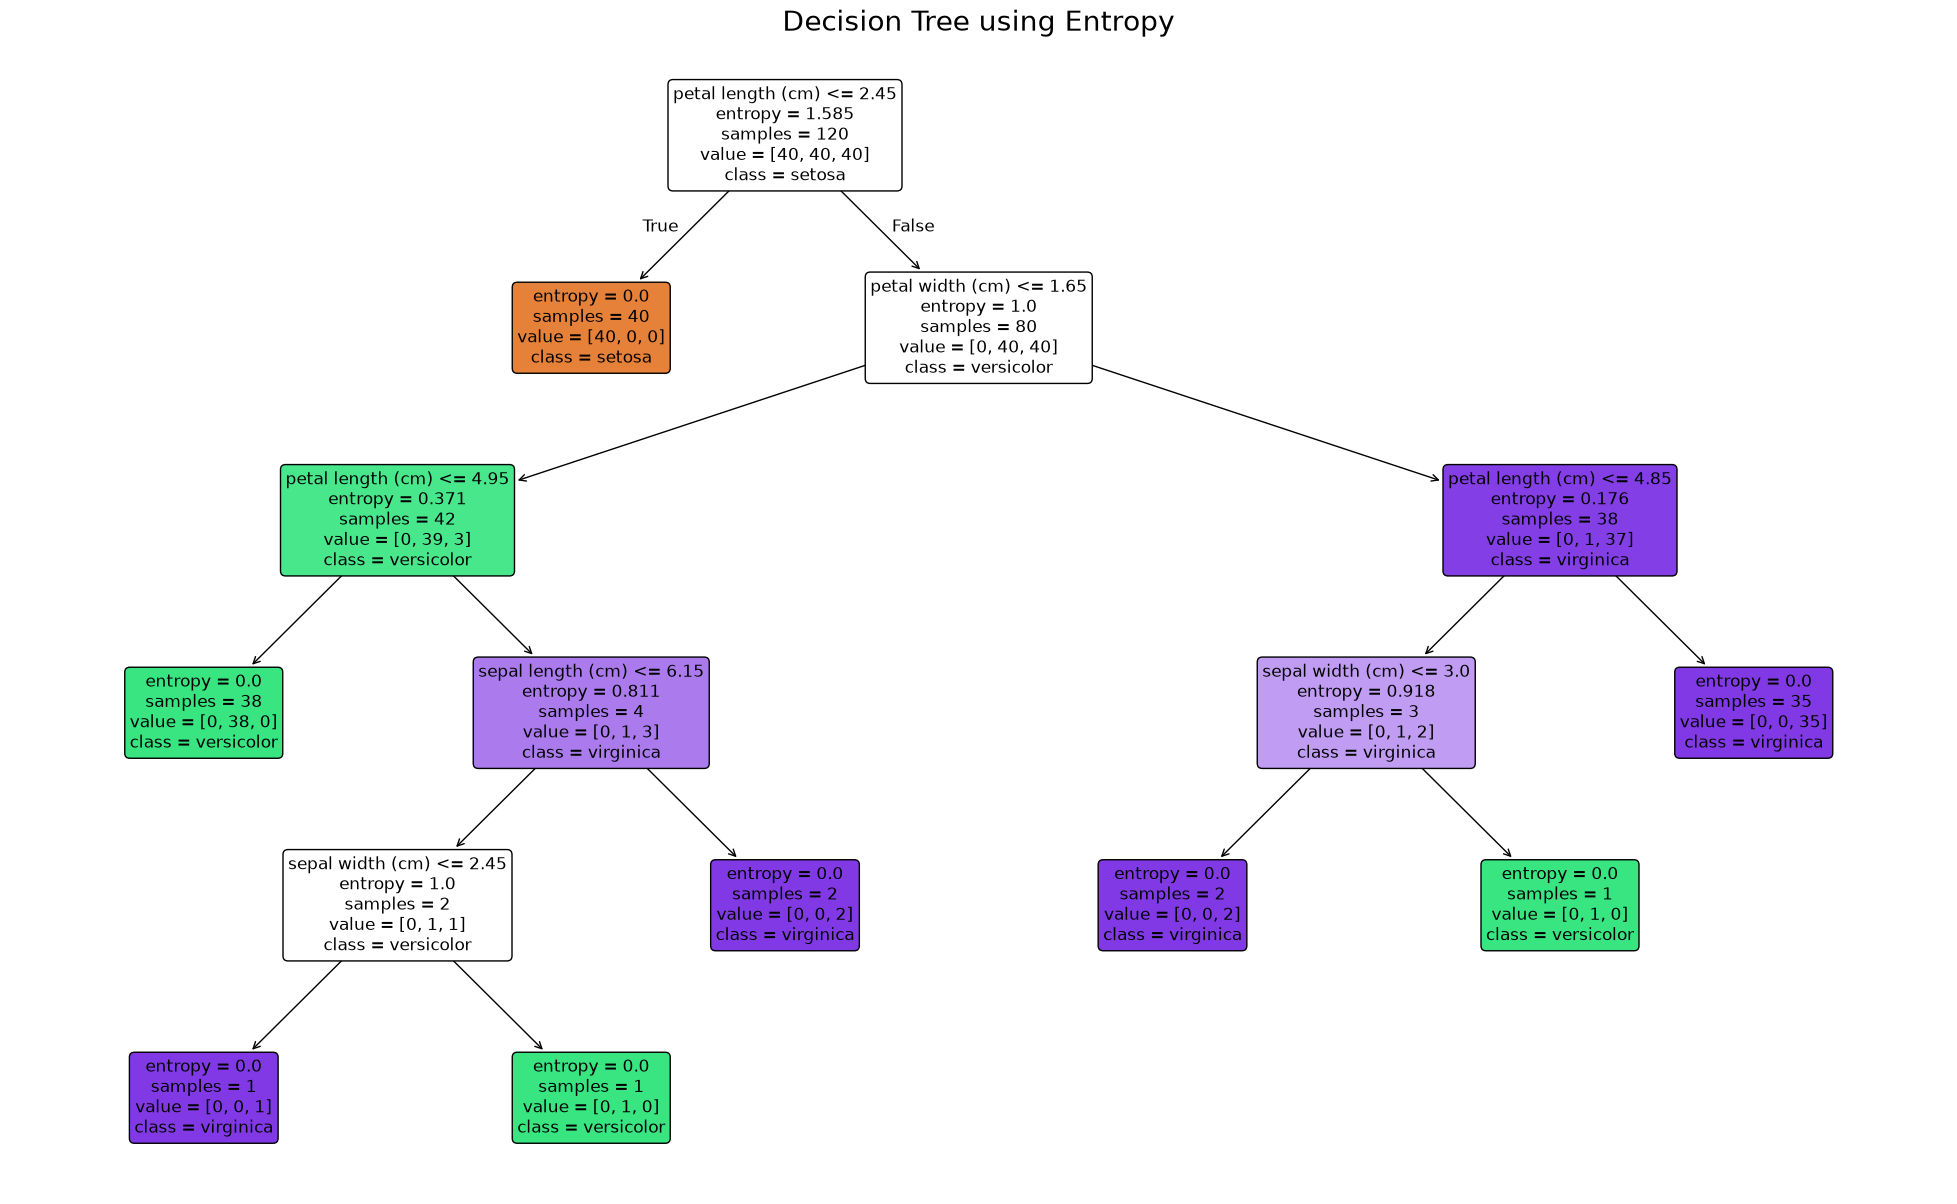

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))

plot_tree(
    dt_entropy,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,  
    fontsize=12    
)

plt.title("Decision Tree using Entropy", fontsize=20)
plt.show()


For one node: 

(petal length (cm) <= 1.9
entropy = 0.918
samples = 120
value = [40, 40, 40]
class = setosa)

(1) petal length (cm) <= 1.9 is split condition

(2) Next value is entropy or the impurity of node (The lower the entropy, the purer the node)

(3) samples = 120: 120 samples passed this node

(4) value [40, 40, 40] : 40 samples -> class 0, 40 samples -> class 1, 40 samples -> class 2

(5) class = setosa: predicted class of node  

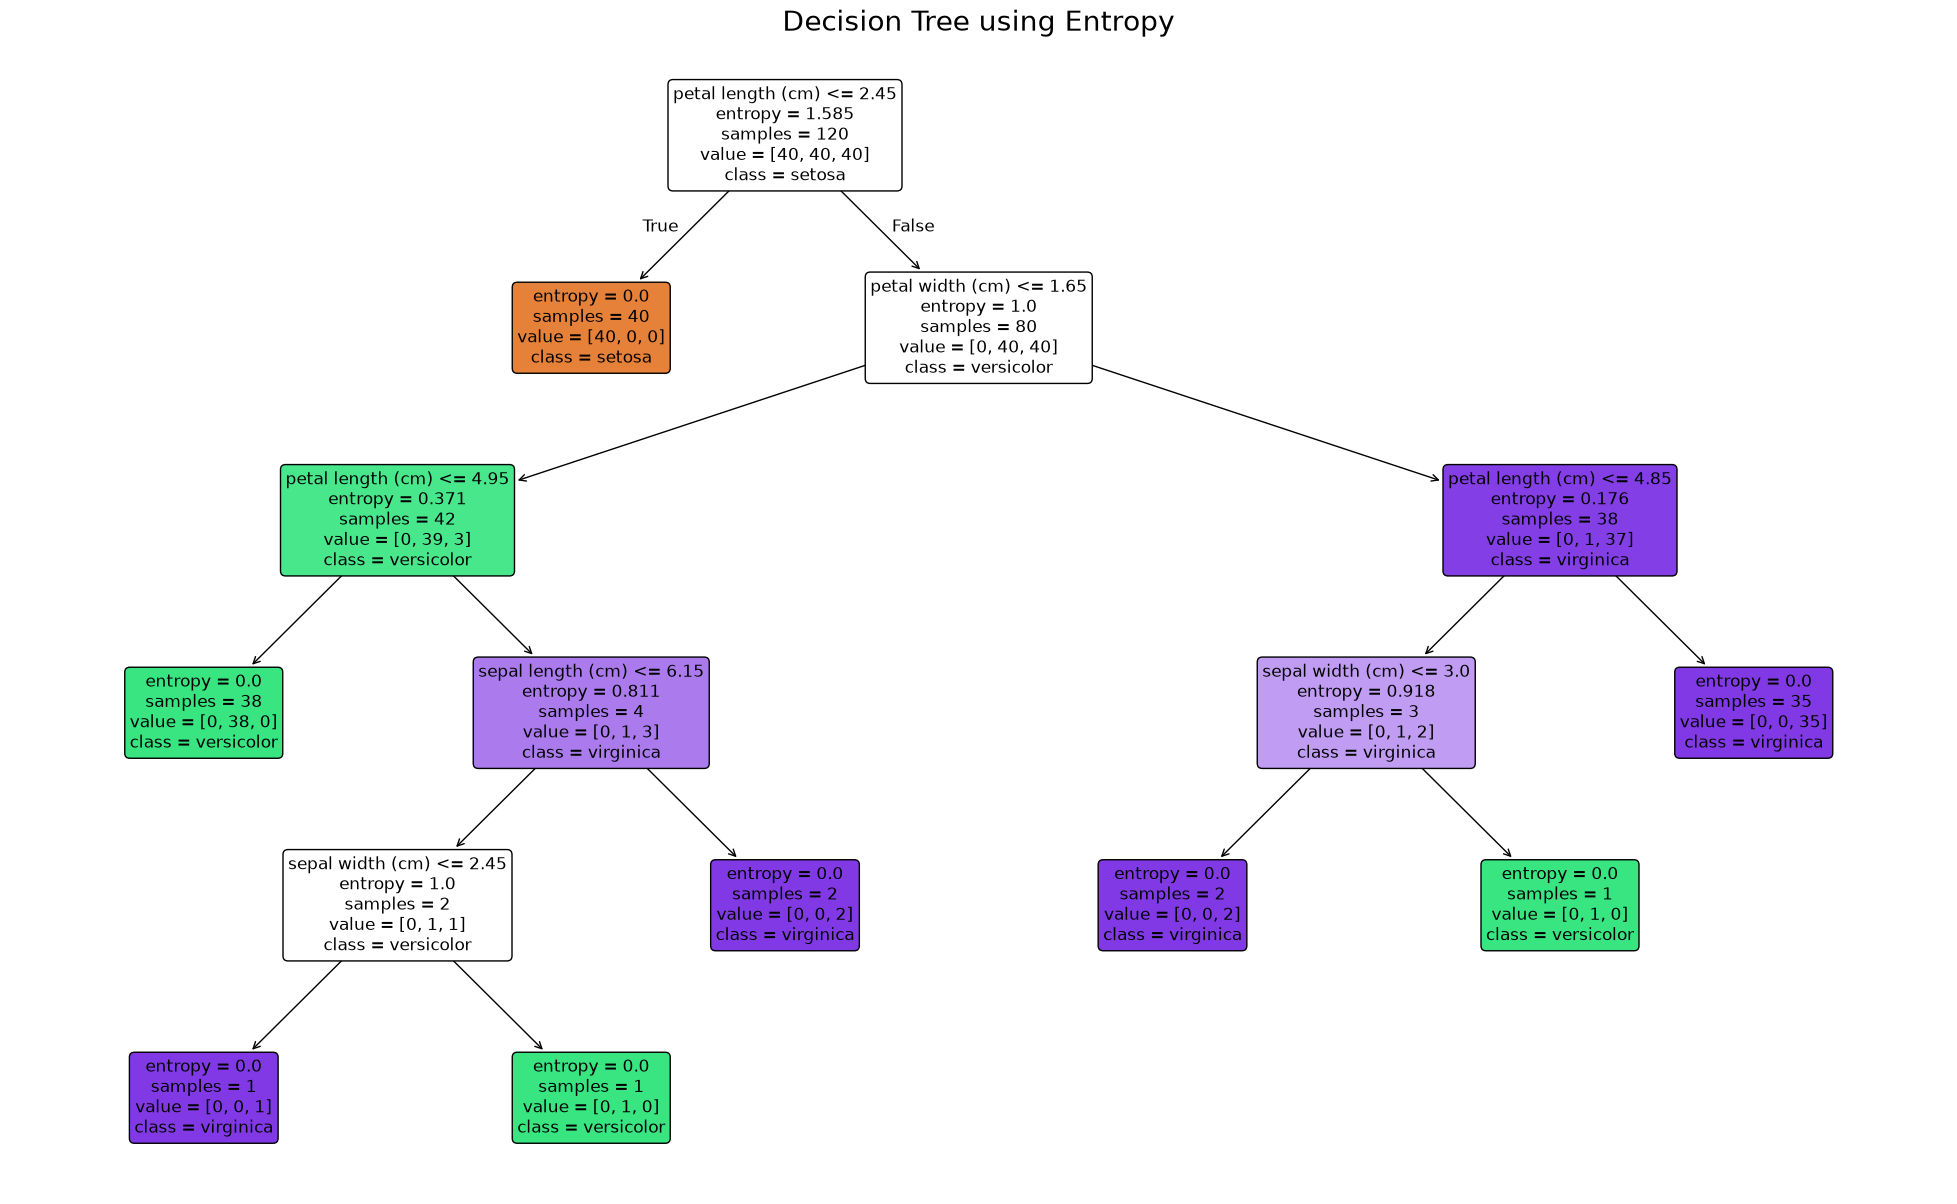

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))

plot_tree(
    dt_entropy,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,  
    fontsize=12    
)

plt.title("Decision Tree using Entropy", fontsize=20)
plt.show()


## Cross-validation

In [30]:
from sklearn.model_selection import cross_val_score

cv_entropy = cross_val_score(
    DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Entropy CV scores:", cv_entropy)
print("Mean accuracy:", cv_entropy.mean())

Entropy CV scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Mean accuracy: 0.9533333333333334


In [31]:
criteria = [
    "entropy",
    "log_loss",
    "gini"
]

cv_results = []

for criterion in criteria:
    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Criterion": criterion,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

cv_results

,Criterion,Mean Accuracy,Std
0,entropy,0.953333,0.033993
1,log_loss,0.953333,0.033993
2,gini,0.953333,0.033993


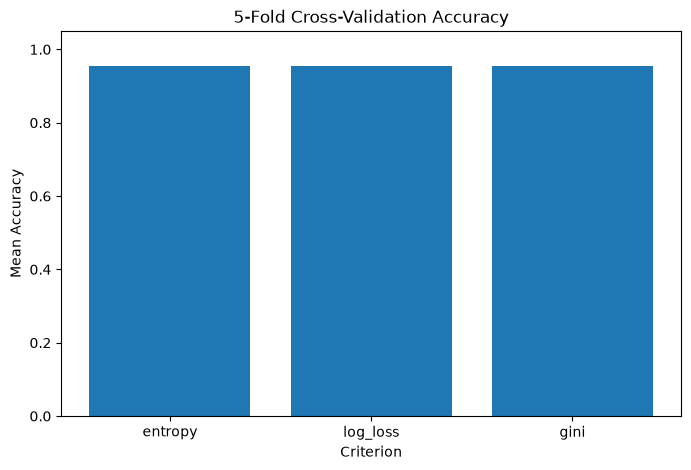

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results["Criterion"],
    cv_results["Mean Accuracy"]
)

plt.xlabel("Criterion")
plt.ylabel("Mean Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")

plt.ylim(0, 1.05)
plt.show()

## Scratch vs Scikit-learn

In [33]:
print("Scratch Decision Tree:")
print("Accuracy:", accuracy_scratch)

print("\nScikit-learn Decision Trees:")

print("Entropy:", accuracy_entropy)
print("Log Loss:", accuracy_log_loss)
print("Gini:", accuracy_gini)

Scratch Decision Tree:
Accuracy: 0.9333333333333333

Scikit-learn Decision Trees:
Entropy: 0.9333333333333333
Log Loss: 0.9333333333333333
Gini: 0.9333333333333333


# Gain Ratio

**Gain Ratio** is the core criterion used in the **C4.5** algorithm. It is an improvement over Information Gain, designed to penalize attributes with a large number of distinct values (which Information Gain naturally favors).

**Formula:**
$$GainRatio(S, A) = \frac{InformationGain(S, A)}{SplitInformation(S, A)}$$
*(Where: $SplitInformation(S, A) = - \sum_{j=1}^{v} \frac{\vert{}S_j\vert{}}{\vert{}S\vert{}} \log_2 \frac{\vert{}S_j\vert{}}{\vert{}S\vert{}}$ measures how broadly and uniformly the attribute $A$ splits the data)*

**Key Characteristics:**
* **Solves Overfitting Bias:** Overcomes Information Gain's flaw of favoring attributes that perfectly split the data into many small subsets but have no predictive value (e.g., User IDs).
* **Penalty Mechanism:** The `SplitInformation` denominator grows as the data is divided into more branches, penalizing features with too many unique values.
* **Application in C4.5:** The algorithm prioritizes the attribute that yields the **highest** Gain Ratio for the next split.

In [34]:
def split_information(y_left, y_right):
    total = len(y_left) + len(y_right)

    p_left = len(y_left) / total
    p_right = len(y_right) / total

    values = []

    if p_left > 0:
        values.append(-p_left * np.log2(p_left))

    if p_right > 0:
        values.append(-p_right * np.log2(p_right))

    return sum(values)

In [35]:
def gain_ratio(y, y_left, y_right):
    gain = information_gain(
        y,
        y_left,
        y_right
    )

    split_info = split_information(
        y_left,
        y_right
    )

    if split_info == 0:
        return 0

    return gain / split_info

In [36]:
gr = gain_ratio(
    y_train,
    left,
    right
)

print("Gain Ratio:", gr)

Gain Ratio: 0.9999999999999999


## Summary

In this experiment, Decision Tree classification was studied using the Iris dataset.

First, a Decision Tree was implemented from scratch using **Entropy** and **Information Gain**. The implementation demonstrated how a tree selects the best feature and threshold recursively until reaching leaf nodes.

Then, `DecisionTreeClassifier` from scikit-learn was used with three splitting criteria:

* **Entropy** — corresponding to the ID3 approach.
* **Log Loss** — an entropy-based criterion.
* **Gini** — commonly used by CART.

The resulting trees were visualized using `plot_tree()`, where each node shows the splitting condition, impurity, number of samples, class distribution, and predicted class.

Finally, **5-fold cross-validation** was performed to evaluate the models more reliably. The mean accuracy and standard deviation were reported for each criterion.
